In [99]:
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore') # To supress warnings

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor

from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.metrics import roc_curve, auc

from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from time import time 

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier


In [3]:
df_loan2 = pd.read_csv(r"C:\METRO Co\Classes\7.MACHINE_LEARNING\ML_PROJECT\Bank_Personal_Loan_Modelling.csv")


In [4]:

df_loan = pd.read_csv(r"C:\METRO Co\Classes\7.MACHINE_LEARNING\ML_PROJECT\Bank_Personal_Loan_Modelling.csv")

print(df_loan.shape)
df_loan.head()

(5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [6]:
print("FIRST 5 ROWS:")
display(df_loan.head())

print("\nLAST 5 ROWS:")
display(df_loan.tail())


FIRST 5 ROWS:


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1



LAST 5 ROWS:


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [7]:
print ("\n","Features : \n\n", df_loan.columns.tolist())


 Features : 

 ['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


In [8]:
# •	Identifying the data types for each variable

df_loan.dtypes


ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

In [9]:
df_loan.nunique()

ID                    5000
Age                     45
Experience              47
Income                 162
ZIP Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal Loan            2
Securities Account       2
CD Account               2
Online                   2
CreditCard               2
dtype: int64

In [10]:
df_loan["Family"].nunique()

4

In [11]:
df_loan2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [12]:
df_loan2.sample(10)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4974,4975,59,33,64,92867,4,1.7,2,0,0,0,0,0,1
170,171,27,1,138,90250,2,2.0,1,0,0,0,0,1,0
3944,3945,56,26,62,91320,3,1.4,3,0,0,0,0,1,0
2642,2643,54,29,81,92096,2,0.0,3,0,0,0,0,1,0
4628,4629,27,1,130,94801,3,2.9,2,0,1,0,0,0,0
1449,1450,63,37,109,90740,1,2.0,1,0,0,0,0,1,0
2678,2679,63,38,148,93023,2,4.3,3,0,1,0,0,1,0
3099,3100,65,40,115,92647,1,2.5,1,174,0,0,0,0,1
2219,2220,52,22,58,93101,4,2.0,3,223,0,0,0,1,0
773,774,41,16,120,92612,2,3.9,1,0,0,0,0,1,1


In [13]:
#•	Determining the number of missing entries per variable: 

df_loan.isnull().sum()


ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [14]:
#•	Identifying and counting duplicate records
df_loan.duplicated().sum()


np.int64(0)

In [15]:
# Convert Education into categorical labels

education_map = {
    1: "Undergrad",
    2: "Graduate",
    3: "Advanced/Professional"
}

df_loan["Education"] = df_loan["Education"].map(education_map)

In [16]:
df_loan["Education"].value_counts()



Education
Undergrad                2096
Advanced/Professional    1501
Graduate                 1403
Name: count, dtype: int64

In [17]:
df_loan.dtypes

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education              object
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

In [18]:
# Identify numeric and categorical variables -- not considering ID and Zip Code
numeric_cols = [
    "Age", "Experience", "Income", "CCAvg",
    "Mortgage"
]

categorical_cols = [
    "Family", "Education", "Personal Loan",
    "Securities Account", "CD Account",
    "Online", "CreditCard"
]


print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']
Categorical columns: ['Family', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


In [19]:
df_loan.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0
Securities Account,5000.0,0.104400,0.305809,0.0,0.00,0.0,0.00,1.0



income, CCAvg and Mortgage show strong right skew → important for LOF outlier detection.

Experience has some invalid negative values, but these are rare.

More than half the customers have no mortgage.

Personal Loan acceptance is only 9.6%, indicating class imbalance.

Binary categorical variables (Online, CreditCard, Securities, CD Account) show diverse usage patterns.

Age distribution is fairly normal but varies from 23 to 67.

In [20]:
df_loan.describe(include='object').T

,count,unique,top,freq
Education,5000,3,Undergrad,2096


In [21]:
# for c in num_cols:
#     plt.figure(figsize=(8,6))
#     sns.histplot(df_classification[c],bins=20, kde= True)
#     plt.title(f"Distribution of {c}")
#     plt.xlabel(c)

    

    
#     plt.show()

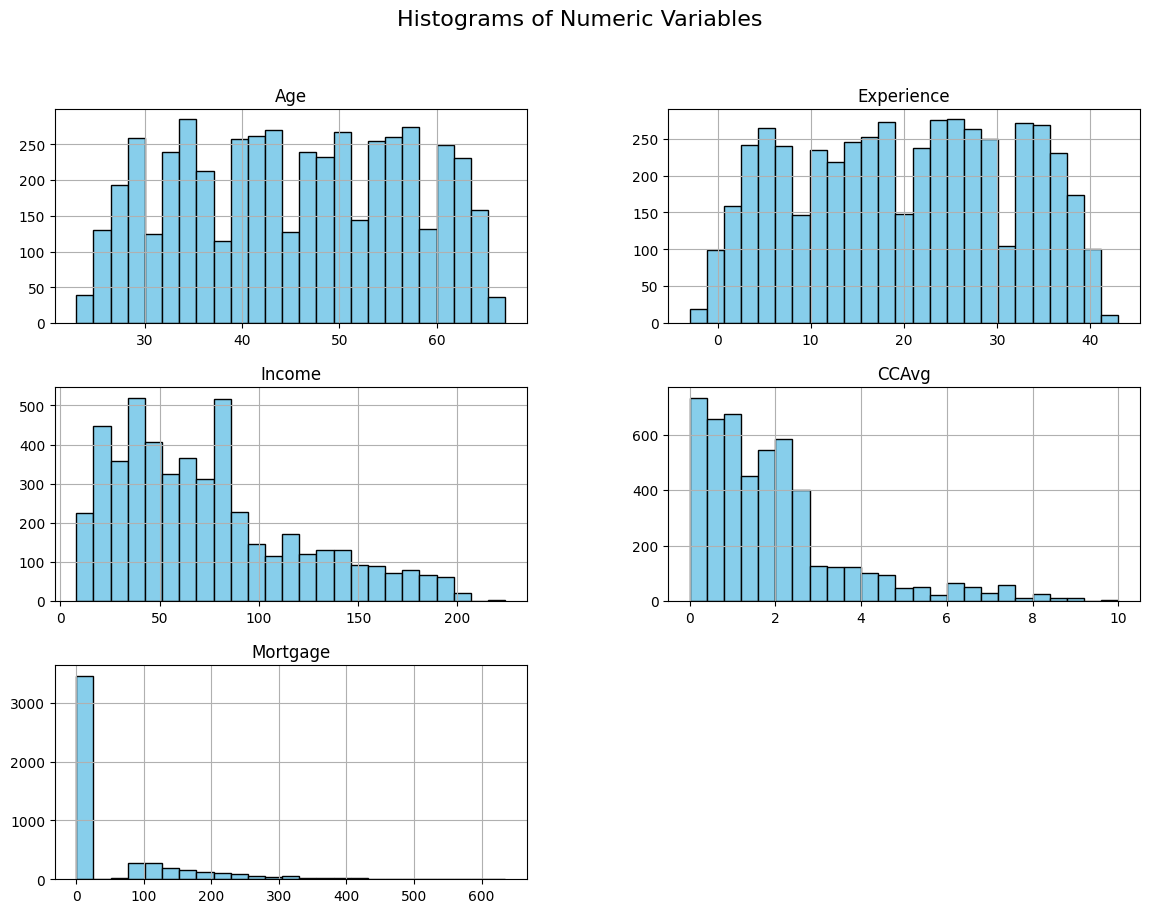

In [22]:
df_loan[numeric_cols].hist(figsize=(14, 10), bins=25,
                           color='skyblue', edgecolor='black')
plt.ylabel("Count")
plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.show()

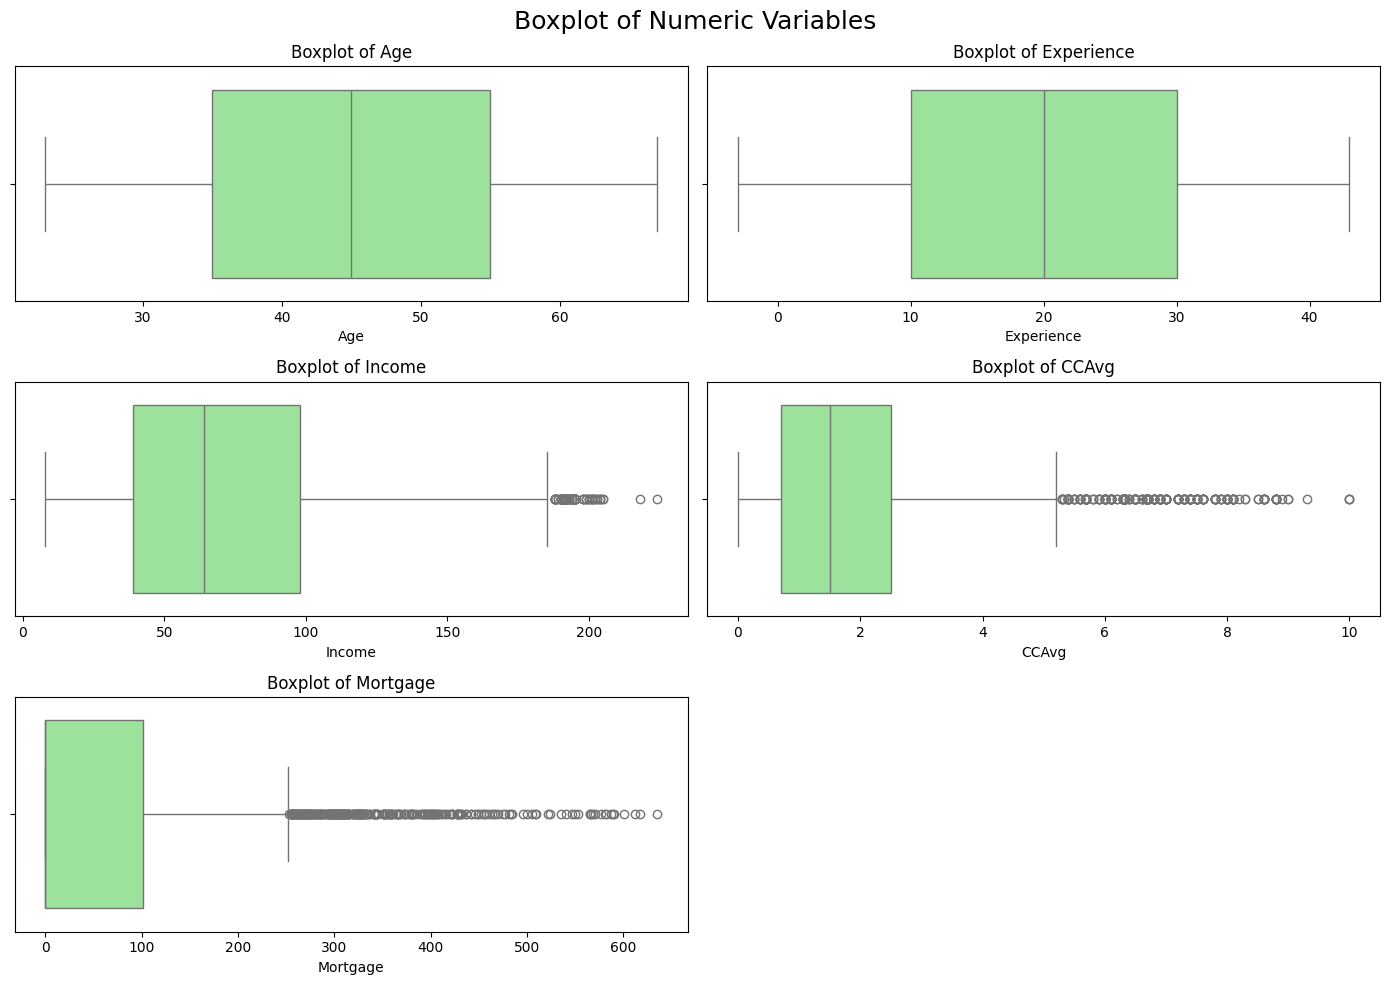

In [25]:
plt.figure(figsize=(14, 10))
plt.suptitle("Boxplot of Numeric Variables", fontsize=18)
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df_loan[col], color="lightgreen")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [26]:
#- ve values in experience:

df_loan[df_loan["Experience"] < 0].shape


(52, 14)

In [27]:
df_loan[df_loan["Experience"] < 0]



,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
89,90,25,-1,113,94303,4,2.30,Advanced/Professional,0,0,0,0,0,1
226,227,24,-1,39,94085,2,1.70,Graduate,0,0,0,0,0,0
315,316,24,-2,51,90630,3,0.30,Advanced/Professional,0,0,0,0,1,0
451,452,28,-2,48,94132,2,1.75,Advanced/Professional,89,0,0,0,1,0
524,525,24,-1,75,93014,4,0.20,Undergrad,0,0,0,0,1,0
536,537,25,-1,43,92173,3,2.40,Graduate,176,0,0,0,1,0
540,541,25,-1,109,94010,4,2.30,Advanced/Professional,314,0,0,0,1,0
576,577,25,-1,48,92870,3,0.30,Advanced/Professional,0,0,0,0,0,1
583,584,24,-1,38,95045,2,1.70,Graduate,0,0,0,0,1,0
597,598,24,-2,125,92835,2,7.20,Undergrad,0,0,1,0,0,1


In [28]:
df_loan[df_loan["Experience"] < 0][["Age", "Experience"]]


,Age,Experience
89,25,-1
226,24,-1
315,24,-2
451,28,-2
524,24,-1
536,25,-1
540,25,-1
576,25,-1
583,24,-1
597,24,-2


In [29]:
df_loan[df_loan["Experience"] < 0].describe().T


,count,mean,std,min,25%,50%,75%,max
ID,52.0,2427.346154,1478.834118,90.0,767.25,2783.5,3669.500,4958.0
Age,52.0,24.519231,1.475159,23.0,24.00,24.0,25.000,29.0
Experience,52.0,-1.442308,0.639039,-3.0,-2.00,-1.0,-1.000,-1.0
Income,52.0,69.942308,37.955295,12.0,40.75,65.5,86.750,150.0
ZIP Code,52.0,93240.961538,1611.654806,90065.0,92167.75,93060.0,94720.000,95842.0
Family,52.0,2.865385,0.970725,1.0,2.00,3.0,4.000,4.0
CCAvg,52.0,2.129423,1.750562,0.2,1.00,1.8,2.325,7.2
Mortgage,52.0,43.596154,90.027068,0.0,0.00,0.0,0.000,314.0
Personal Loan,52.0,0.000000,0.000000,0.0,0.00,0.0,0.000,0.0
Securities Account,52.0,0.115385,0.322603,0.0,0.00,0.0,0.000,1.0


In [30]:
df_loan[df_loan["Experience"] < 0][["Age","Experience"]]


,Age,Experience
89,25,-1
226,24,-1
315,24,-2
451,28,-2
524,24,-1
536,25,-1
540,25,-1
576,25,-1
583,24,-1
597,24,-2


Replacing negative Experience values with their absolute values was considered.
However, this approach was rejected because the absolute magnitude of the negative values does not reflect true years of working experience and would artificially inflate experience for younger customers. Instead, negative values were replaced with 0, which is a reasonable and realistic assumption for customers aged 23–29.

In [31]:
df_loan.loc[df_loan["Experience"] < 0, "Experience"] = 0


In [32]:
df_loan["Experience"] 

0        1
1       19
2       15
3        9
4        8
        ..
4995     3
4996     4
4997    39
4998    40
4999     4
Name: Experience, Length: 5000, dtype: int64

In [33]:
df_loan["Experience"].mean()

np.float64(20.1196)

After replacing the 52 negative Experience values with 0, the mean Experience increased slightly from 20.1046 to 20.1196 years. This minimal change confirms that the correction did not distort the distribution of the Experience variable or introduce bias. Since the negative values were only 1% of the dataset and concentrated in younger customers, setting them to 0 preserved the overall structure and realism of the data.

In [34]:
# for col in cat_cols:
#     plt.figure(figsize=(8,4))
#     order = df_classification[col].value_counts().index
    
#     sns.countplot(
#         data=df_classification,
#         x=col,
#         order=order,
#         hue=col,              # 
#         palette='pastel',
#         legend=False           # avoids duplicate legend
#     )
    
#     plt.title(f"Distribution of {col}", fontsize=13)
#     plt.xlabel(col)
#     plt.ylabel("Count")
#     plt.xticks(rotation=30, ha='right')
#     plt.tight_layout()
#     plt.show()

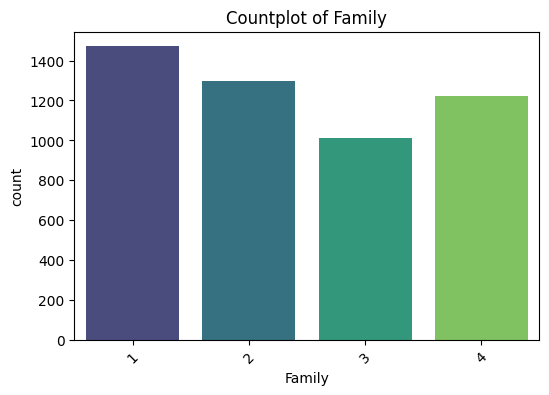


Value counts for Family:
Family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64



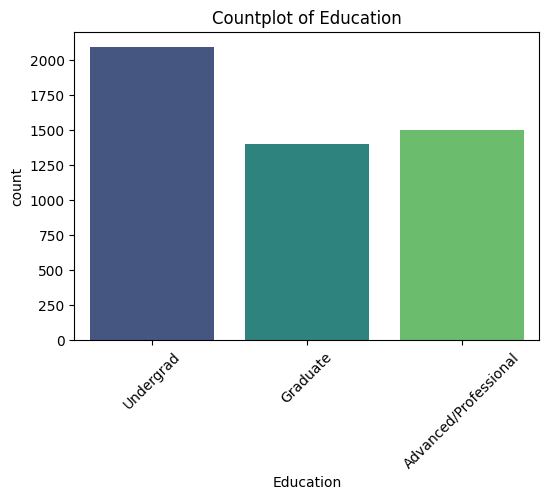


Value counts for Education:
Education
Undergrad                2096
Advanced/Professional    1501
Graduate                 1403
Name: count, dtype: int64



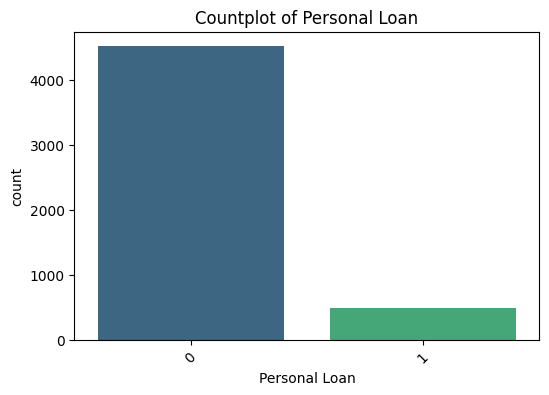


Value counts for Personal Loan:
Personal Loan
0    4520
1     480
Name: count, dtype: int64



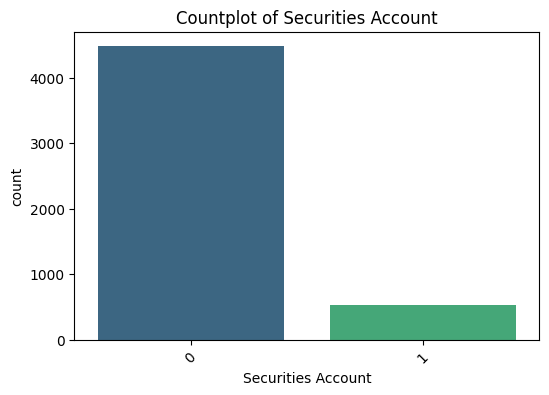


Value counts for Securities Account:
Securities Account
0    4478
1     522
Name: count, dtype: int64



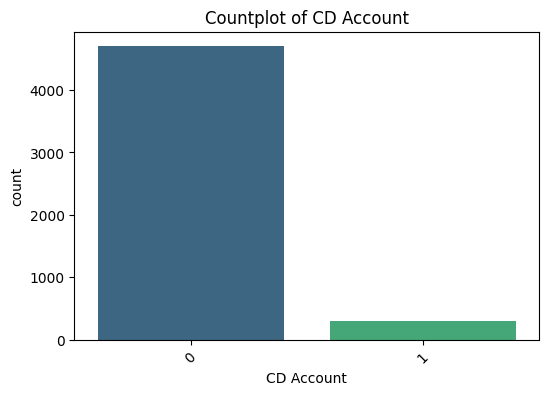


Value counts for CD Account:
CD Account
0    4698
1     302
Name: count, dtype: int64



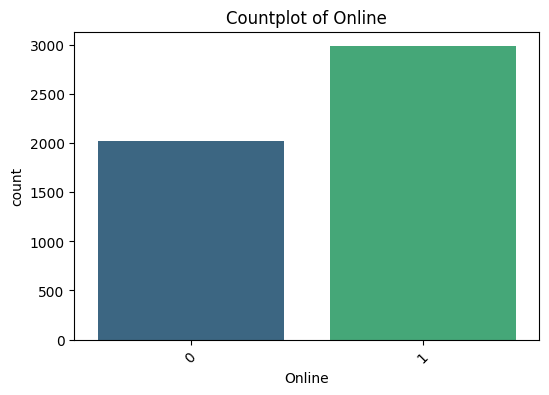


Value counts for Online:
Online
1    2984
0    2016
Name: count, dtype: int64



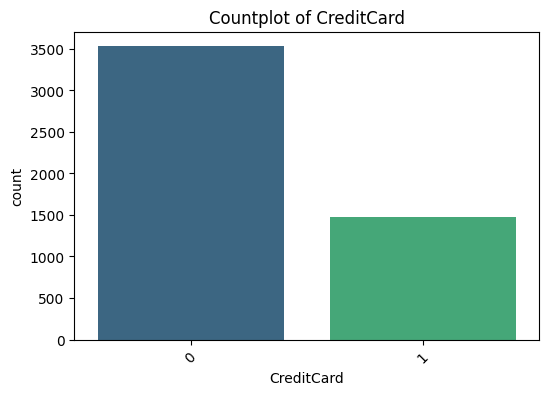


Value counts for CreditCard:
CreditCard
0    3530
1    1470
Name: count, dtype: int64



In [35]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_loan, x=col, palette="viridis")
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

    print(f"\nValue counts for {col}:\n{df_loan[col].value_counts()}\n")


### 7.	Outlier detection: Use the Local Outlier Factor (LoF) method to identify outliers:

Local Outlier Factor (LOF) is a density-based anomaly detection algorithm that identifies outliers by comparing the local density of each data point with the densities of its nearest neighbors. The key idea is that normal observations lie in areas of similar density, while outliers exist in sparser regions. LOF uses k-nearest neighbors to compute each point’s local density and then calculates an LOF score: values close to 1.0 indicate normal points, whereas values significantly greater than 1 indicate potential anomalies. Because LOF focuses on local structure rather than the entire dataset, it works well for datasets with clusters of varying densities and can detect subtle, context-specific outliers that global methods (like Z-score or IQR) may miss. However, it is sensitive to the choice of the number of neighbors (k) and can be computationally expensive on very large datasets.

* A point is flagged as an outlier if:

Its local density is much lower than the density of its neighbors.

Mathematically, LOF produces a score:

LOF ≈ 1.0 → normal observations

LOF > 1.0 → potential anomaly

LOF >> 1.5 – 2.0 → strong outliers



In [36]:
#We will use only continuous numeric features

lof_numeric_cols = ["Age", "Experience", "Income", "CCAvg", "Mortgage"]
X_lof = df_loan[lof_numeric_cols]


In [37]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)  # 5% expected outliers
y_pred = lof.fit_predict(X_lof)

In [38]:
# LOF scores (negative_outlier_factor_)
lof_scores = lof.negative_outlier_factor_
lof_scores

array([-1.11898704, -1.07070957, -1.02078185, ..., -1.00525054,
       -1.1798643 , -0.99037784], shape=(5000,))

In [39]:

# Add outlier info to dataframe
df_loan["LOF_Score"] = lof_scores
df_loan["Outlier_LOF"] = np.where(y_pred == -1, 1, 0)

# Count outliers
outlier_count = df_loan["Outlier_LOF"].sum()
inlier_count = len(df_loan) - outlier_count

outlier_count, inlier_count

(np.int64(250), np.int64(4750))

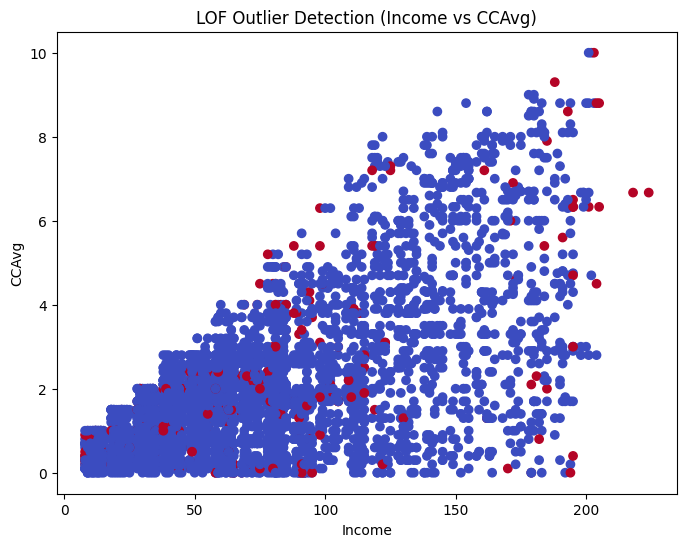

In [40]:

plt.figure(figsize=(8,6))
plt.scatter(df_loan["Income"], df_loan["CCAvg"], 
            c=df_loan["Outlier_LOF"], cmap="coolwarm")
plt.xlabel("Income")
plt.ylabel("CCAvg")
plt.title("LOF Outlier Detection (Income vs CCAvg)")
plt.show()


Local Outlier Factor (LOF) identified 250 outliers in the dataset. After analyzing their distribution, these outliers were retained rather than removed. In banking and financial datasets, extreme values often represent genuine customer behaviors (e.g., high-income or high-spending individuals) rather than data entry errors. Removing them would result in loss of meaningful variation and may negatively impact the model’s ability to generalize. Therefore, the LOF results were documented for analysis but the observations were not removed from the dataset.

In [41]:
#Chi-Square Test — Education vs Personal Loan

# Contingency table
ct = pd.crosstab(df_loan["Education"], df_loan["Personal Loan"])
print("Contingency Table:")
print(ct)

Contingency Table:
Personal Loan             0    1
Education                       
Advanced/Professional  1296  205
Graduate               1221  182
Undergrad              2003   93


In [42]:
# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

print("\nChi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("\nExpected Frequencies:")
print(expected)


Chi-square Statistic: 111.2398718738913
Degrees of Freedom: 2
P-value: 6.991473868665428e-25

Expected Frequencies:
[[1356.904  144.096]
 [1268.312  134.688]
 [1894.784  201.216]]


### Hypotheses:

H0 (Null Hypothesis): Education level and Personal Loan acceptance are independent.

H1 (Alternative Hypothesis): Education level and Personal Loan acceptance are dependent

The Chi-square test was conducted to examine whether education level is associated with personal loan acceptance. The test produced a chi-square statistic of 111.24 with 2 degrees of freedom and a p-value  is far below the 0.05 significance threshold. Therefore, we reject the null hypothesis and conclude that Education and Personal Loan acceptance are statistically dependent.

From the contingency table, customers with Graduate and Advanced/Professional education levels show significantly higher loan acceptance rates (≈13%) compared to Undergraduate customers (≈4.4%). This indicates that higher-educated customers are more likely to accept personal loan offers. This insight is valuable for targeted marketing and segmentation strategies.

Higher education → Significantly higher loan acceptance

Acceptance Rate=(loan(1))/(loan(0)+loan(1))

In [43]:
df_loan.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard', 'LOF_Score', 'Outlier_LOF'],
      dtype='object')

In [44]:
#dropping ID and ZIP Code
numeric_cols

['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

In [45]:
#dropping ID and ZIP Code
df_corr =  df_loan[numeric_cols]


In [46]:
df_corr.head()

,Age,Experience,Income,CCAvg,Mortgage
0,25,1,49,1.6,0
1,45,19,34,1.5,0
2,39,15,11,1.0,0
3,35,9,100,2.7,0
4,35,8,45,1.0,0


In [47]:
corr_matrix = df_corr.corr()

corr_matrix

,Age,Experience,Income,CCAvg,Mortgage
Age,1.000000,0.994198,-0.055269,-0.052012,-0.012539
Experience,0.994198,1.000000,-0.046729,-0.049912,-0.010840
Income,-0.055269,-0.046729,1.000000,0.645984,0.206806
CCAvg,-0.052012,-0.049912,0.645984,1.000000,0.109905
Mortgage,-0.012539,-0.010840,0.206806,0.109905,1.000000


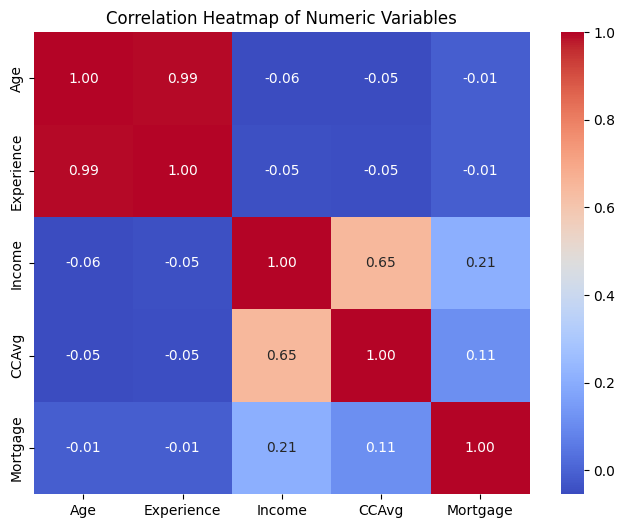

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


#### Interpretation of the Correlation Matrix
* 1. Age and Experience (r = 0.994) — Very Strong Positive Correlation
Age and Experience exhibit an almost perfect positive correlation. This is expected, as older customers generally have more years of work experience.

* 2. Income and CCAvg (r = 0.646) — Strong Positive Correlation
Customers with higher income tend to spend more on credit cards. This relationship is intuitive and confirms that spending behavior is partially driven by income level.

* 3. Income and Mortgage (r = 0.207) — Weak-to-Moderate Positive Correlation
Higher income customers are somewhat more likely to have larger mortgage values, though the relationship is not strong. This may suggest diverse financial profiles across income levels.

* 4. CCAvg and Mortgage (r = 0.110) — Very Weak Positive Correlation
These two variables show minimal relationship.
Credit card spending behavior does not strongly relate to mortgage amounts.


    """
    Iteratively removes one feature from each pair of highly correlated variables
    until no pair has correlation above the threshold.
    Always keeps the protected_feature (e.g., Age).
    
    Parameters:
        df (pd.DataFrame): Dataframe with numeric variables
        threshold (float): Correlation threshold
        protected_feature (str): Column that should NEVER be removed
        
    Returns:
        list: Remaining features after removing high-correlation variables
    """


In [49]:
def remove_high_corr_features(df, threshold=0.8, protected_feature="Age"):

    df_corr = df.copy()
    iteration = 1

    while True:
        corr_matrix = df_corr.corr().abs()

        # Find all pairs above threshold
        high_corr_pairs = []
        for col1 in corr_matrix.columns:
            for col2 in corr_matrix.columns:
                if col1 != col2 and corr_matrix.loc[col1, col2] > threshold:
                    high_corr_pairs.append((col1, col2))

        # If no high-correlation pairs → stop
        if not high_corr_pairs:
            break

        print(f"\nIteration {iteration}: High Correlation Pairs Found:")
        print(high_corr_pairs)

        # Count occurrences of each column in the high-correlation pairs
        freq = {}
        for col1, col2 in high_corr_pairs:
            freq[col1] = freq.get(col1, 0) + 1
            freq[col2] = freq.get(col2, 0) + 1

        # Pick the column with highest frequency for removal
        col_to_remove = max(freq, key=freq.get)

        # If the selected column is the protected one (e.g., Age), remove the *other* variable
        if col_to_remove == protected_feature:
            # Remove whichever column paired with Age
            for col1, col2 in high_corr_pairs:
                if col1 == protected_feature:
                    col_to_remove = col2
                    break
                elif col2 == protected_feature:
                    col_to_remove = col1
                    break

        print(f" → Removing column: {col_to_remove}")

        # Drop the selected column
        df_corr = df_corr.drop(columns=[col_to_remove])
        iteration += 1

    print("\nFinal remaining columns with acceptable correlation:")
    print(list(df_corr.columns))
    return list(df_corr.columns)


In [50]:
numeric_cols = ["Age", "Experience", "Income", "CCAvg", "Mortgage"]

df_numeric = df_loan[numeric_cols]

remaining_features = remove_high_corr_features(df_numeric, threshold=0.8, protected_feature="Age")



Iteration 1: High Correlation Pairs Found:
[('Age', 'Experience'), ('Experience', 'Age')]
 → Removing column: Experience

Final remaining columns with acceptable correlation:
['Age', 'Income', 'CCAvg', 'Mortgage']


In [51]:
# after removing high collinearity

df_check = df_loan[remaining_features]

corr_new = df_check.corr().abs()
corr_new


,Age,Income,CCAvg,Mortgage
Age,1.000000,0.055269,0.052012,0.012539
Income,0.055269,1.000000,0.645984,0.206806
CCAvg,0.052012,0.645984,1.000000,0.109905
Mortgage,0.012539,0.206806,0.109905,1.000000


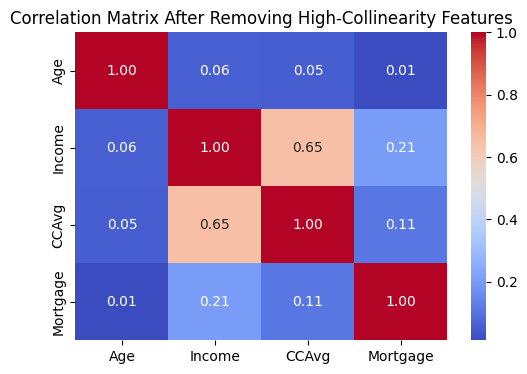

In [52]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_new, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix After Removing High-Collinearity Features")
plt.show()

* - After removing highly correlated variables using an iterative collinearity removal function, the remaining predictors (Age, Income, CCAvg, Mortgage) were re-evaluated. The updated correlation matrix confirmed that all remaining correlations were below the threshold of 0.80, indicating that collinearity was successfully resolved.
     

In [53]:
#VIF Calculation 

# Use only the remaining features
df_vif = df_loan[remaining_features].copy()

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) 
                   for i in range(df_vif.shape[1])]

vif_data

,Feature,VIF
0,Age,3.023899
1,Income,5.868278
2,CCAvg,3.825399
3,Mortgage,1.364543


* Variance Inflation Factor (VIF) was computed for the remaining numerical predictors (Age, Income, CCAvg, Mortgage) after removing highly correlated variables. All VIF values were below 5, confirming that the predictors do not exhibit high multicollinearity.

Since multicollinearity has been successfully addressed, all remaining variables were retained for modeling.

### Step 10 — Encoding the Categorical Variables

In [54]:
categorical_cols

['Family',
 'Education',
 'Personal Loan',
 'Securities Account',
 'CD Account',
 'Online',
 'CreditCard']

In [55]:
df_loan[categorical_cols].dtypes

Family                 int64
Education             object
Personal Loan          int64
Securities Account     int64
CD Account             int64
Online                 int64
CreditCard             int64
dtype: object

In [56]:


df_encoded = df_loan.copy()
df_encoded.head(1)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,LOF_Score,Outlier_LOF
0,1,25,1,49,91107,4,1.6,Undergrad,0,0,1,0,0,0,-1.118987,0


In [57]:
#Encoding Education
# Drop unusable columns
df_model = df_loan.drop(columns=["ID", "ZIP Code", "Experience", 
                                 "LOF_Score", "Outlier_LOF"])

# One-hot encode Education
df_model = pd.get_dummies(df_model, columns=["Education"], drop_first=True)

df_model.head()


,Age,Income,Family,CCAvg,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Education_Graduate,Education_Undergrad
0,25,49,4,1.6,0,0,1,0,0,0,False,True
1,45,34,3,1.5,0,0,1,0,0,0,False,True
2,39,11,1,1.0,0,0,0,0,0,0,False,True
3,35,100,1,2.7,0,0,0,0,0,0,True,False
4,35,45,4,1.0,0,0,0,0,0,1,True,False


In [58]:
#11.Split the dataset into training and testing subsets.

# Define target and predictors
X = df_model.drop(columns=["Personal Loan"])
y = df_model["Personal Loan"]

In [59]:
# Train-test split (80/20 )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 11), (1000, 11), (4000,), (1000,))

The dataset was divided into training and testing subsets using an 80:20 split ratio. Stratified sampling was applied to ensure the proportion of loan-accepting and non-accepting customers remained consistent in both subsets.

In [60]:
from sklearn.preprocessing import StandardScaler


In [61]:
#Step 12: Scaling the Numerical Predictors
# Models like KNN, SVM, Logistic Regression, and PCA require scaled data.

In [62]:
scaler = StandardScaler()

# Fit the scaler on training data, then transform both
    
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Scaling completed successfully.\n\n")
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
display("X_train_scaled: ",X_train_scaled.head())
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
display("X_test_scaled: ",X_test_scaled.head())

 Scaling completed successfully.




'X_train_scaled: '

,Age,Income,Family,CCAvg,Mortgage,Securities Account,CD Account,Online,CreditCard,Education_Graduate,Education_Undergrad
408,1.268346,0.335098,-0.332080,0.505071,-0.553909,-0.340693,-0.255988,0.818199,-0.639878,-0.618972,1.173332
3737,-0.124436,-0.938772,-1.201969,-0.817714,-0.553909,-0.340693,-0.255988,0.818199,-0.639878,-0.618972,-0.852274
3889,-1.691316,-1.176273,-1.201969,-1.047763,0.643609,-0.340693,-0.255988,0.818199,-0.639878,1.615583,-0.852274
568,-0.994925,-0.701271,-0.332080,-1.047763,1.039483,-0.340693,-0.255988,0.818199,1.562799,-0.618972,1.173332
1041,0.920150,-0.485361,1.407697,-0.242590,-0.553909,-0.340693,-0.255988,-1.222197,-0.639878,-0.618972,1.173332


'X_test_scaled: '

,Age,Income,Family,CCAvg,Mortgage,Securities Account,CD Account,Online,CreditCard,Education_Graduate,Education_Undergrad
2388,1.616541,-1.089909,0.537809,-0.817714,-0.553909,2.935198,-0.255988,-1.222197,-0.639878,-0.618972,1.173332
2373,-1.081974,2.386245,-0.332080,1.655318,-0.553909,-0.340693,-0.255988,-1.222197,-0.639878,1.615583,-0.852274
4347,1.094248,-1.111500,0.537809,-0.990251,-0.553909,-0.340693,-0.255988,0.818199,-0.639878,-0.618972,1.173332
665,0.746052,-0.269451,1.407697,0.044972,-0.553909,2.935198,-0.255988,0.818199,-0.639878,-0.618972,-0.852274
4182,0.833101,-0.528543,-0.332080,-0.645177,1.623398,-0.340693,-0.255988,-1.222197,1.562799,-0.618972,-0.852274


* * Standardization was applied to the predictor variables using StandardScaler. The scaler was fit only on the training data to prevent data leakage, and the same scaling parameters were applied to the test data. Scaling ensures that models such as Logistic Regression, KNN, SVM, and PCA perform optimally by placing all numerical features on a comparable scale.

In [63]:
#13.Perform PCA. Based on outcome, recommend if Principal Components would be useful for data preparation or not. 

In [64]:
from sklearn.decomposition import PCA

In [65]:
pca = PCA()
pca.fit(X_train_scaled)


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [66]:
# Transform train and test
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("explained_variance \n ",explained_variance)
print("cumulative_variance \n", cumulative_variance)

explained_variance 
  [0.18597126 0.13745588 0.11510719 0.0938921  0.09214471 0.08824052
 0.08618118 0.08120942 0.04700073 0.04179905 0.03099795]
cumulative_variance 
 [0.18597126 0.32342714 0.43853434 0.53242644 0.62457115 0.71281167
 0.79899285 0.88020227 0.927203   0.96900205 1.        ]


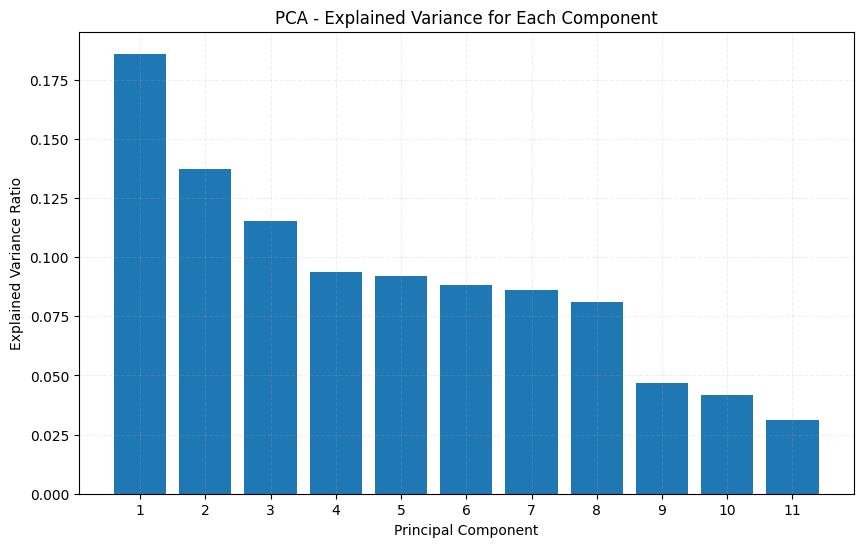

In [67]:
plt.figure(figsize=(10,6))
plt.bar(range(1, len(explained_variance)+1), explained_variance)
plt.xlabel("Principal Component")
plt.xticks(range(1, len(explained_variance)+1))
plt.ylabel("Explained Variance Ratio")
plt.grid(linestyle='--',alpha=.2)
plt.title("PCA - Explained Variance for Each Component")
plt.show()


* Explained variance tells you how much of the total information each PC contains.
here:
 - PC1 captures 18.6% of the total variance
 - PC2 captures 13.7% and so on..

Each component captures less information than the previous one.

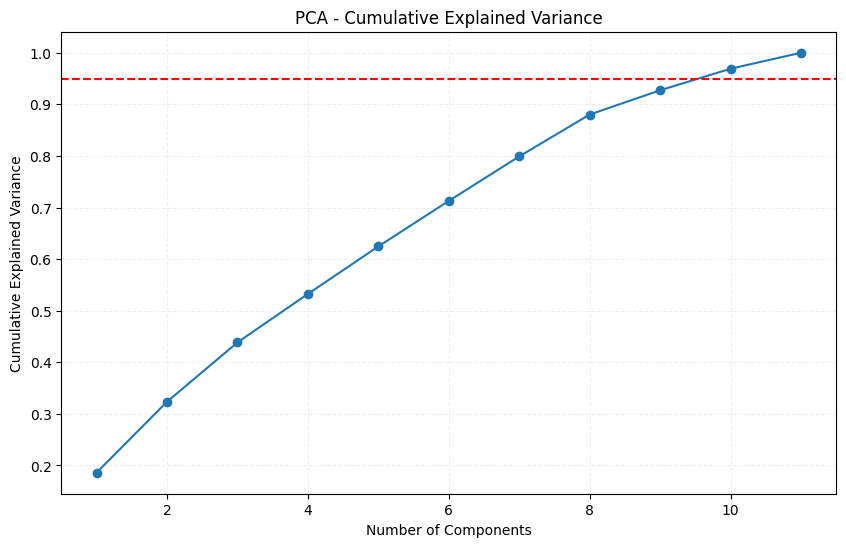

In [68]:
plt.figure(figsize=(10,6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.axhline(y=0.95, color='r', linestyle='--')
plt.grid(linestyle='--',alpha=.2)
plt.show()


* Principal Component Analysis (PCA) was applied to the standardized predictor variables to examine the underlying structure and determine whether dimensionality reduction would be beneficial.

The explained variance plot showed that no single component accounts for a large proportion of variance. The first principal component explains 18.6%, and it takes eight components to reach 88% cumulative variance. Achieving 95% variance requires ten components, which is almost the entire feature set.

These results indicate that the dataset does not contain strong latent factors, and the variables are not highly redundant. Therefore, PCA does not provide meaningful dimensionality reduction, and the PCA-transformed components were not used for model building. The original predictors were retained for the classification models.

# Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [70]:
# Train the model
log_reg = LogisticRegression(max_iter=500,n_jobs=-1)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [71]:
# Predictions
y_train_pred_lr = log_reg.predict(X_train_scaled)
y_test_pred_lr = log_reg.predict(X_test_scaled)

y_test_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [72]:
# Metrics
print("\nLogistic Regression Metrics:")
print("*"*30)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("Precision:", precision_score(y_test, y_test_pred_lr))
print("Recall:", recall_score(y_test, y_test_pred_lr))
print("F1 Score:", f1_score(y_test, y_test_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_lr))


# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_lr))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lr))


Logistic Regression Metrics:
******************************
Train Accuracy: 0.959
Test Accuracy: 0.96
Precision: 0.85
Recall: 0.7083333333333334
F1 Score: 0.7727272727272727
ROC-AUC: 0.9614675516224189

Confusion Matrix:
[[892  12]
 [ 28  68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       904
           1       0.85      0.71      0.77        96

    accuracy                           0.96      1000
   macro avg       0.91      0.85      0.88      1000
weighted avg       0.96      0.96      0.96      1000



The model achieved a test accuracy of 96% and a ROC-AUC of 0.96, indicating excellent ability to distinguish between customers who accepted and did not accept a personal loan.
The close alignment between train accuracy (95.9%) and test accuracy (96.0%) shows no evidence of overfitting.

- Precision = 0.85
  - When the model predicts a customer will accept a loan, it is correct 85% of the time.
- Recall = 0.708
  - The model correctly identifies about 71% of all customers who actually accepted the loan.
 
* *

True Negative (892): Correctly predicted no-loan customers
False Positive (12): Predicted loan acceptance but they did not accept

False Negative (28): Missed actual loan accepters (important for the bank)
True Positive (68): Correctly flagged loan accepters

# MODEL 2: SVM with GridSearchCV

In [73]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score


#### PRE-SEARCH #1  — VARY C(regularization)

In [74]:

C_values = [0.01, 0.1, 1, 10,30, 50,70, 100]
cv_results_C = []
test_f1_results = []

for c in C_values:
    svm_temp = SVC(C=c, kernel='rbf', gamma='scale')
    svm_temp.fit(X_train_scaled, y_train)
    f1 = cross_val_score(
        svm_temp, 
        X_train_scaled, 
        y_train, 
        cv=5, 
        scoring="f1"
    )

    y_pred_temp = svm_temp.predict(X_test_scaled)
    cv_results_C.append(f1.mean())
    acc = accuracy_score(y_test, y_pred_temp)
    
    test_f1 = f1_score(y_test, y_pred_temp)
    test_f1_results.append(test_f1)

    print(f"C : {c} | Train cv : {f1.mean()} | Test :  {test_f1}")




C : 0.01 | Train cv : 0.0 | Test :  0.0
C : 0.1 | Train cv : 0.5792650750604706 | Test :  0.7236842105263158
C : 1 | Train cv : 0.848265979209447 | Test :  0.8863636363636364
C : 10 | Train cv : 0.8631281577681961 | Test :  0.91005291005291
C : 30 | Train cv : 0.8589749596450365 | Test :  0.90625
C : 50 | Train cv : 0.8488981629753655 | Test :  0.9119170984455959
C : 70 | Train cv : 0.8475695820043645 | Test :  0.9109947643979057
C : 100 | Train cv : 0.842685775734977 | Test :  0.8969072164948454


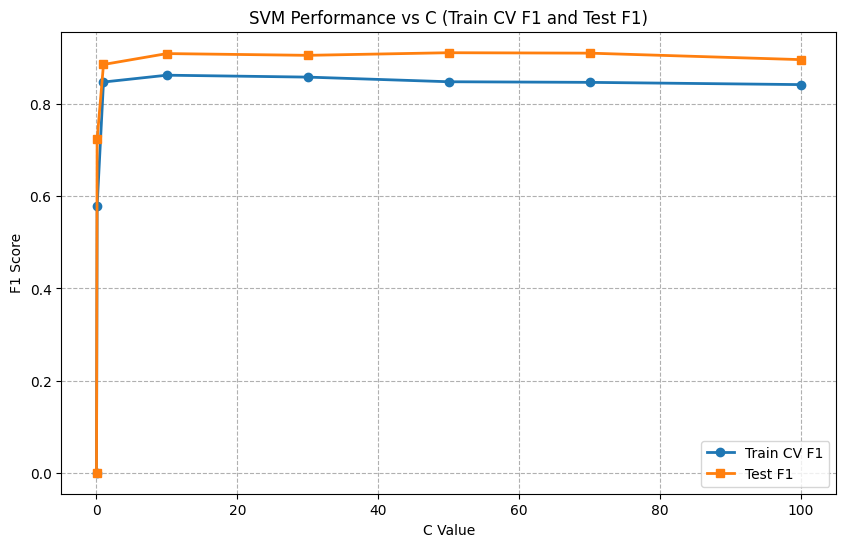

In [75]:
plt.figure(figsize=(10,6))

# plot train cv f1
plt.plot(C_values, cv_results_C, marker='o', label='Train CV F1', linewidth=2)

# plot test f1
plt.plot(C_values, test_f1_results, marker='s', label='Test F1', linewidth=2)


plt.xlabel("C Value")
plt.ylabel("F1 Score")
plt.title("SVM Performance vs C (Train CV F1 and Test F1)")
plt.grid(linestyle='--')
plt.legend()
plt.show()

The results show that very small values of C (0.01, 0.1) lead to severe underfitting. Performance improves substantially for C = 1, and peaks at C = 10, where both train CV F1 and test F1 are maximized. Higher values of C (30–70) produce stable performance but do not improve beyond C = 10, while extremely high values (C = 100) begin to show signs of overfitting.

Based on this analysis, the most appropriate C values to include in GridSearchCV are [1, 10, 30, 50].

#### PRE-SEARCH #2 — VARY gamma

In [76]:
gamma_values = ["scale", 0.1, 0.01, 0.001]
cv_results_gamma = []

train_cv_g = []
test_f1_g = []

for g in gamma_values:
    svm_temp = SVC(C=10, kernel='rbf', gamma=g)
    
    # CV F1 score
    f1_cv = cross_val_score(
        svm_temp,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()
    train_cv_g.append(f1_cv)
    
    # Test F1 score
    svm_temp.fit(X_train_scaled, y_train)
    y_pred_test = svm_temp.predict(X_test_scaled)
    f1_test = f1_score(y_test, y_pred_test)
    test_f1_g.append(f1_test)
    
    cv_results_gamma.append((g, f1_cv, f1_test))

cv_results_gamma


[('scale', np.float64(0.8631281577681961), 0.91005291005291),
 (0.1, np.float64(0.8631252742504103), 0.9157894736842105),
 (0.01, np.float64(0.8346258740615774), 0.9162011173184358),
 (0.001, np.float64(0.7001300622425422), 0.7402597402597403)]

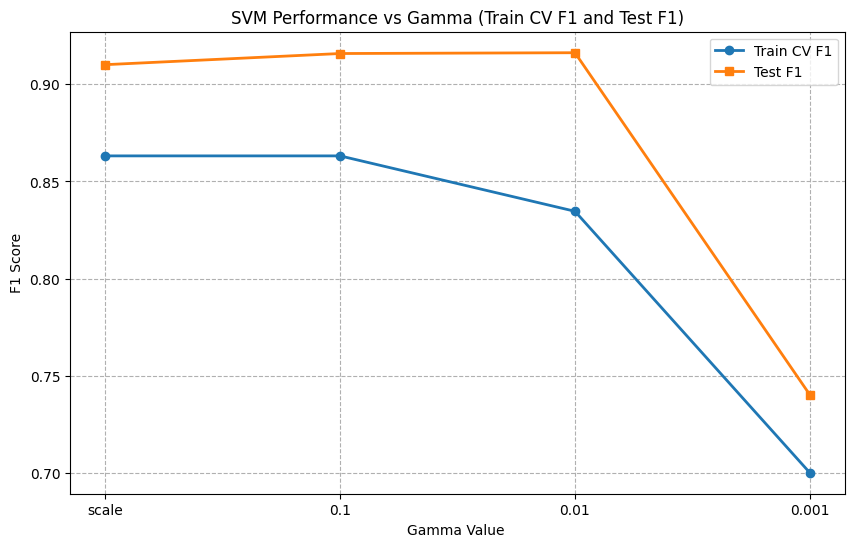

In [77]:
plt.figure(figsize=(10,6))

# plot train cv f1
plt.plot(gamma_values, train_cv_g, marker='o', label='Train CV F1', linewidth=2)

# plot test f1
plt.plot(gamma_values, test_f1_g, marker='s', label='Test F1', linewidth=2)


plt.xlabel("Gamma Value ")
plt.ylabel("F1 Score")
plt.title("SVM Performance vs Gamma (Train CV F1 and Test F1)")
plt.grid(linestyle='--')
plt.legend()
plt.show()

* Gamma = 0.1: Excellent
Highest test F1 among all
Train CV also extremely strong

* gamma = scale: Also excellent

(This is equivalent to gamma = 1 / (n_features * X.var))

* gamma = 0.01 : Very good

Slightly lower train CV but great test performance

 * gamma = 0.001 : not good, Underfitting

 * gamma = ['scale', 0.1, 0.01]


In [78]:
from time import time 
from sklearn.model_selection import GridSearchCV

#### FINAL SVM GridSearchCV

In [79]:
svm_params = {
    "C": [1, 10, 30, 50],
    "gamma": ["scale", 0.1, 0.01],
    "kernel": ["rbf", "poly"],
    "degree": [2, 3]   # applied only when kernel='poly'
}

start = time()
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

end = time()- start





In [80]:
print(f"Time taken:  {end} seconds")

Time taken:  58.697813749313354 seconds


In [81]:

print("Best Parameters:", svm_grid.best_params_)



Best Parameters: {'C': 50, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}


Even though degree appears in best_params, it has NO effect on RBF kernel.
So the real winning combination is:

* *  kernel = 'rbf'
* * C = 50
* * gamma = 0.01

In [82]:
#evaluating this best SVM model
best_svm = svm_grid.best_estimator_

In [83]:
# Predictions
y_train_pred_svm = best_svm.predict(X_train_scaled)
y_test_pred_svm = best_svm.predict(X_test_scaled)

# Probabilities for ROC-AUC
y_test_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

print("\nSVM Metrics:")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_svm))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_svm))

print("F1 Score:", f1_score(y_test, y_test_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_svm))



SVM Metrics:
Train Accuracy: 0.98525
Test Accuracy: 0.988
F1 Score: 0.9354838709677419
ROC-AUC: 0.993858314896755

Confusion Matrix:
[[901   3]
 [  9  87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       904
           1       0.97      0.91      0.94        96

    accuracy                           0.99      1000
   macro avg       0.98      0.95      0.96      1000
weighted avg       0.99      0.99      0.99      1000



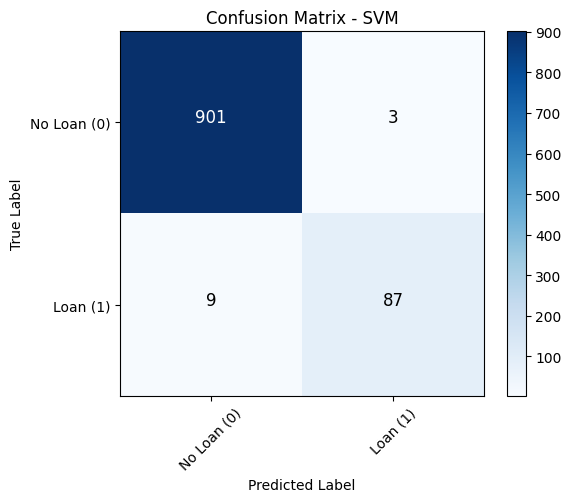

In [84]:
cm = confusion_matrix(y_test, y_test_pred_svm)
classes = ['No Loan (0)', 'Loan (1)']

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Print numbers inside cells
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=12)

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


The confusion matrix for the optimized SVM classifier shows extremely strong classification performance. Out of 904 true negative cases, only 3 were misclassified as loan accepters (false positives). Similarly, only 9 out of 96 loan accepters were missed (false negatives). This indicates that the SVM model achieves a very low error rate while maintaining excellent recall for the positive class.

A Support Vector Machine classifier was tuned using GridSearchCV, exploring different combinations of C, gamma, and kernel types (RBF and polynomial). Pre-search sensitivity analysis was performed to determine optimal ranges for C and gamma before hyperparameter tuning. Based on GridSearchCV, the best-performing model was obtained with:

C = 50
gamma = 0.01
kernel = ‘rbf’

The polynomial kernel was also evaluated, but the RBF kernel consistently outperformed it.

The optimized SVM model achieved a test accuracy of 98.8%, which is higher than both Logistic Regression and all baseline models. More importantly, the model achieved a recall of 0.906 and an F1-score of 0.935 for the positive class (loan accepted). This indicates excellent ability to correctly identify customers who are likely to accept a loan.

The ROC-AUC score of 0.9939 is exceptionally high, indicating near-perfect class separability across all thresholds. The confusion matrix shows very few misclassifications, with only 3 false positives and 9 false negatives, demonstrating balanced performance and low error rates.

Overall, the SVM model provides the strongest predictive performance among all tested algorithms and is highly effective in identifying potential loan accepters.

# Random Forest Modelling

#### Pre-search #1  for n_estimator

In [85]:
n_values =[10, 20, 50, 70, 90, 100, 150, 200]

train_cv_rf = []
test_score_rf = []
results_n = []

for n in n_values:
    rf_temp = RandomForestClassifier(
        n_estimators=n, 
        random_state=42,
        n_jobs=-1
    )
    
    # Train CV F1
    f1_cv = cross_val_score(
        rf_temp,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()
    train_cv_rf.append(f1_cv)
    
    # Test F1
    rf_temp.fit(X_train, y_train)
    y_pred_test = rf_temp.predict(X_test)
    f1_test = f1_score(y_test, y_pred_test)
    test_score_rf.append(f1_test)
    
    results_n.append((n, round(f1_cv, 4), round(f1_test, 4)))

results_n

[(10, np.float64(0.8826), 0.9355),
 (20, np.float64(0.9082), 0.9424),
 (50, np.float64(0.9135), 0.9579),
 (70, np.float64(0.9163), 0.9634),
 (90, np.float64(0.9146), 0.9579),
 (100, np.float64(0.9177), 0.9579),
 (150, np.float64(0.9164), 0.9579),
 (200, np.float64(0.9162), 0.9579)]

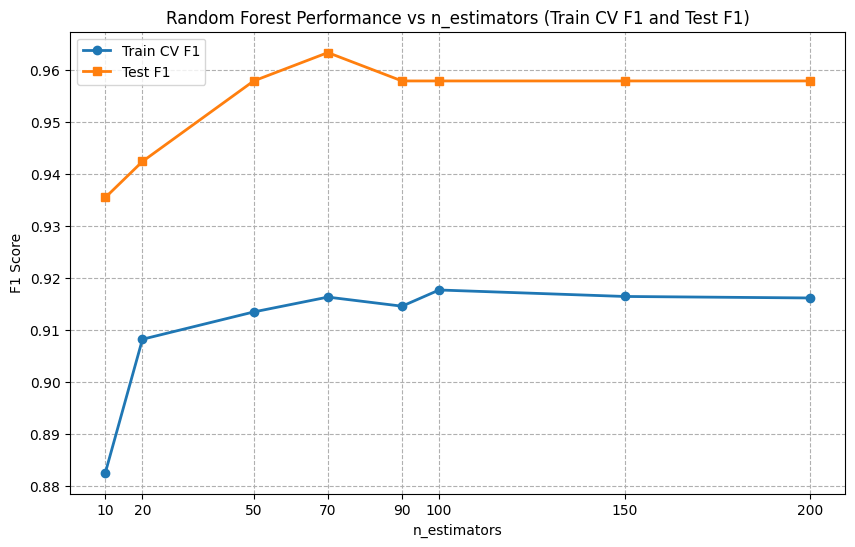

In [86]:
plt.figure(figsize=(10,6))

# plot train cv f1
plt.plot(n_values, train_cv_rf, marker='o', label='Train CV F1', linewidth=2)

# plot test f1
plt.plot(n_values, test_score_rf, marker='s', label='Test F1', linewidth=2)


plt.xlabel("n_estimators")
plt.xticks(n_values)
plt.ylabel("F1 Score")
plt.title("Random Forest Performance vs n_estimators (Train CV F1 and Test F1)")
plt.grid(linestyle='--')
plt.legend()
plt.show()

* 10 and 20 trees underperform
→ Not enough trees, higher variance.

* Performance stabilizes at 50 trees

→ Good "minimum useful number" of trees.

*  Best test performance at n = 70 (F1 = 0.9634)
But test performance varies slightly — this might be noise

n_estimators = [50,60 70,80 100, 120]


#### Pre-search #2:  for max_depth

In [87]:
depth_values = [ 5, 7, 10,12,14, None]

results_depth = []
train_score_md =[]
test_score_md =[]
for d in depth_values:
    rf_temp = RandomForestClassifier(
        n_estimators=100,   # stable middle value
        max_depth=d,
        random_state=42,
        n_jobs=-1
    )
    
    # Train CV F1
    f1_cv = cross_val_score(
        rf_temp,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()
    train_score_md.append(f1_cv)
    
    # Test F1
    rf_temp.fit(X_train, y_train)
    y_pred_test = rf_temp.predict(X_test)
    f1_test = f1_score(y_test, y_pred_test)
    test_score_md.append(f1_test)
    
    results_depth.append((d, round(f1_cv, 4), round(f1_test, 4)))

results_depth


[(5, np.float64(0.8513), 0.929),
 (7, np.float64(0.9048), 0.9468),
 (10, np.float64(0.9117), 0.9579),
 (12, np.float64(0.9146), 0.9634),
 (14, np.float64(0.915), 0.9583),
 (None, np.float64(0.9177), 0.9579)]

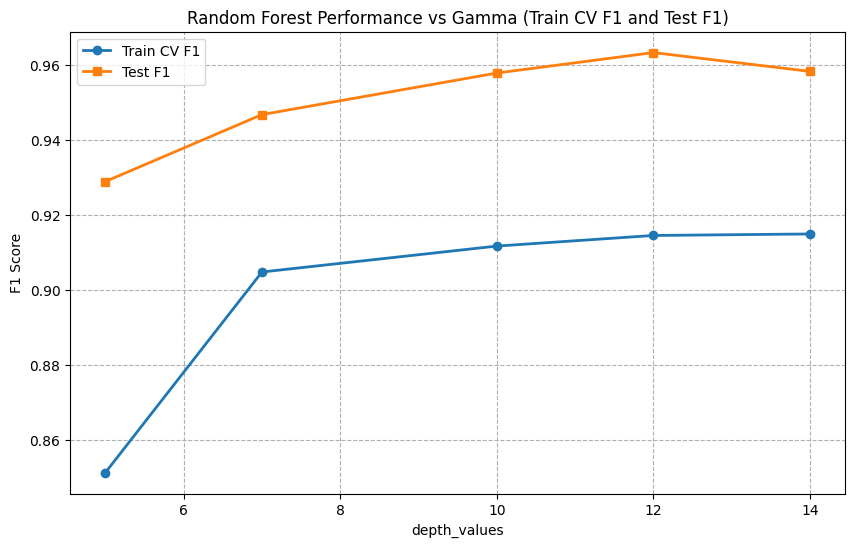

In [88]:
plt.figure(figsize=(10,6))

# plot train cv f1
plt.plot(depth_values, train_score_md, marker='o', label='Train CV F1', linewidth=2)

# plot test f1
plt.plot(depth_values, test_score_md, marker='s', label='Test F1', linewidth=2)


plt.xlabel("depth_values")

plt.ylabel("F1 Score")
plt.title("Random Forest Performance vs Gamma (Train CV F1 and Test F1)")
plt.grid(linestyle='--')
plt.legend()
plt.show()

* * * max_depth = 7

Good performance

A strong candidate

* * * max_depth = 10

Consistently strong

Good balance of bias–variance

Very stable training and testing performance

* * * max_depth = 12

Best test performance overall (F1 = 0.9634)

Slight improvement over depth 10

No sign of overfitting

choosen max_depth = [7, 10, 12]


#### Pre-search#3: for min_samples_split


In [89]:
split_values = [2, 5, 10, 20]

results_split = []
train_score_mss =[]
test_score_mss =[]
for s in split_values:
    rf_temp = RandomForestClassifier(
        n_estimators=100,   # stable value
        max_depth=12,       # best from pre-search
        min_samples_split=s,
        random_state=42,
        n_jobs=-1
    )
    
    # Train CV F1
    f1_cv = cross_val_score(
        rf_temp,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()
    train_score_mss.append(f1_cv)
    # Test F1
    rf_temp.fit(X_train, y_train)
    y_pred_test = rf_temp.predict(X_test)
    f1_test = f1_score(y_test, y_pred_test)
    test_score_mss.append( f1_test)
    
    results_split.append((s, round(f1_cv, 4), round(f1_test, 4)))

results_split


[(2, np.float64(0.9146), 0.9634),
 (5, np.float64(0.9174), 0.9579),
 (10, np.float64(0.9119), 0.9529),
 (20, np.float64(0.9005), 0.9424)]

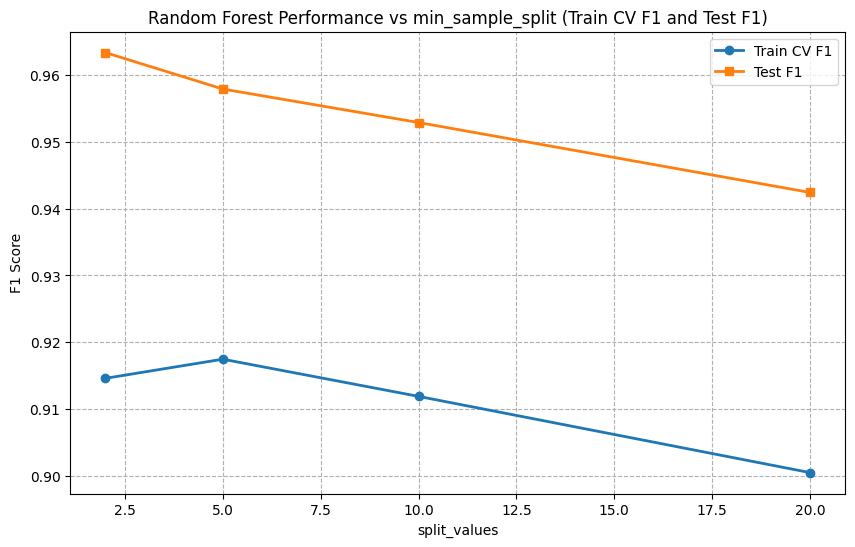

In [90]:
plt.figure(figsize=(10,6))

# plot train cv f1
plt.plot(split_values, train_score_mss, marker='o', label='Train CV F1', linewidth=2)

# plot test f1
plt.plot(split_values, test_score_mss, marker='s', label='Test F1', linewidth=2)


plt.xlabel("split_values")

plt.ylabel("F1 Score")
plt.title("Random Forest Performance vs min_sample_split (Train CV F1 and Test F1)")
plt.grid(linestyle='--')
plt.legend()
plt.show()

* * min_samples_split = 2
Best test F1-score
Deepest splits
No overfitting (based on test metric)


* * min_samples_split = 5
Nearly identical to split=2
Slightly higher CV F1 (more stable)

- min_samples_split = [2, 5, 7]



### FINAL Random Forest GridSearchCV

In [91]:
# Final parameter grid based on pre-search analysis
rf_params = {
    "n_estimators": [50, 60, 70, 100, 120],
    "max_depth": [7, 10, 12],
    "min_samples_split": [2, 5, 7]
}

In [92]:
# Grid Search (using F1-score, because dataset is imbalanced)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
# Fit on training data (unscaled – RF does NOT need scaling)
rf_grid.fit(X_train, y_train)


Fitting 5 folds for each of 45 candidates, totalling 225 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [7, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 60, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [93]:
# Best model
best_rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 100}


In [94]:


# Predictions
y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

# Probabilities for ROC-AUC
y_test_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Metrics:")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Precision:", precision_score(y_test, y_test_pred_rf))
print("Recall:", recall_score(y_test, y_test_pred_rf))
print("F1 Score:", f1_score(y_test, y_test_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf))



Random Forest Metrics:
Train Accuracy: 0.99725
Test Accuracy: 0.992
Precision: 0.9680851063829787
Recall: 0.9479166666666666
F1 Score: 0.9578947368421052
ROC-AUC: 0.9987555309734513

Confusion Matrix:
[[901   3]
 [  5  91]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       904
           1       0.97      0.95      0.96        96

    accuracy                           0.99      1000
   macro avg       0.98      0.97      0.98      1000
weighted avg       0.99      0.99      0.99      1000



* * The best-performing model was obtained with:

max_depth = 12, min_samples_split = 5, n_estimators = 100

This optimized Random Forest achieved a test accuracy of 99.2%, along with exceptionally high values for precision (0.968), recall (0.948), and F1-score (0.958) for the positive class. The model also achieved a ROC-AUC score of 0.9988, indicating near-perfect separability between customers who accepted and did not accept a loan.

The confusion matrix shows only 3 false positives and 5 false negatives, demonstrating the model’s ability to accurately identify both loan accepters and non-accepters, with minimal misclassification. Random Forest performed slightly better than both Logistic Regression and SVM, making it the strongest model overall for this classification task.

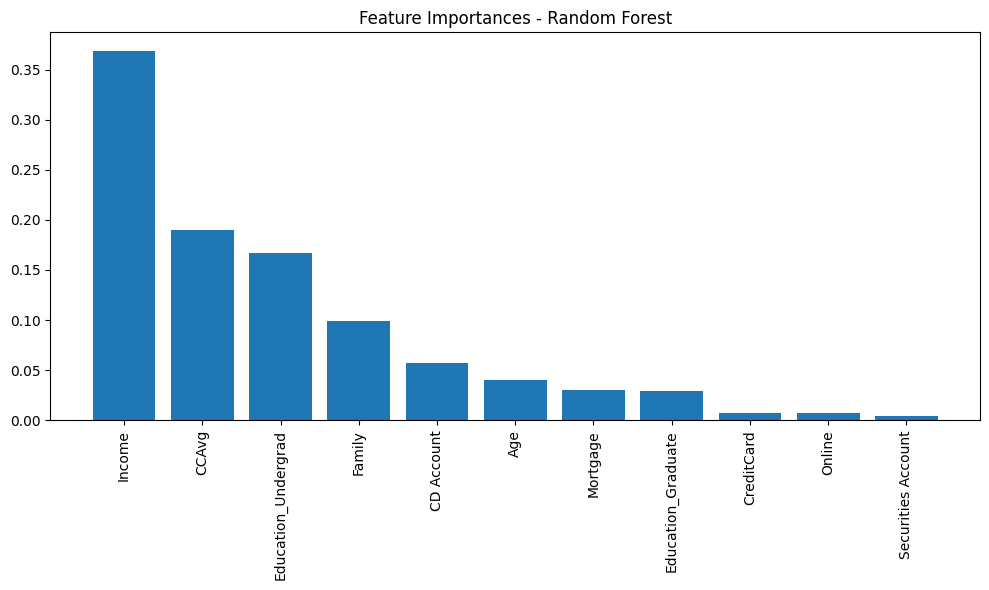

In [95]:

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.title("Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

* ----

* The Random Forest model provides feature importance scores that quantify the contribution of each variable to loan acceptance prediction. The most influential predictor was Income (0.3688), indicating that higher-income customers are significantly more likely to accept a personal loan. The next most important variables were CCAvg (0.19) and Education_Undergrad (0.1673), suggesting that lifestyle spending and educational background play major roles in loan decisions. Additional contributors include Family size and CD account ownership, whereas features such as Online banking usage, CreditCard usage, and Securities account showed minimal predictive value. These insights highlight which customer characteristics drive loan acceptance behavior and provide actionable guidance for targeted marketing strategies.

# KNN

In [96]:
from sklearn.neighbors import KNeighborsClassifier

In [97]:
X_test_scaled.shape, X_train_scaled.shape

((1000, 11), (4000, 11))

#### Pre-search #1: for Best K (1 to 30)

In [98]:
k1 = range(1,31)
results_knn = []
train_knn =[]
test_knn=[]
for k in range(1, 31):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    
    # 5-fold CV on TRAINING data
    f1_cv = cross_val_score(
        knn_temp, X_train_scaled, y_train,
        cv=5, scoring="f1"
    ).mean()
    train_knn.append(f1_cv)
    # Test-set F1 Score
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    f1_test = f1_score(y_test, y_pred_temp)
    test_knn.append(f1_test)
    results_knn.append((k, round(f1_cv, 4), round(f1_test, 4)))

results_knn

[(1, np.float64(0.7571), 0.7933),
 (2, np.float64(0.6775), 0.7654),
 (3, np.float64(0.7622), 0.8),
 (4, np.float64(0.6914), 0.7516),
 (5, np.float64(0.7346), 0.773),
 (6, np.float64(0.6652), 0.7105),
 (7, np.float64(0.7117), 0.7595),
 (8, np.float64(0.6563), 0.702),
 (9, np.float64(0.6837), 0.7516),
 (10, np.float64(0.6381), 0.6933),
 (11, np.float64(0.6671), 0.702),
 (12, np.float64(0.629), 0.6712),
 (13, np.float64(0.6618), 0.7067),
 (14, np.float64(0.6055), 0.6621),
 (15, np.float64(0.6282), 0.6892),
 (16, np.float64(0.5938), 0.6528),
 (17, np.float64(0.6107), 0.6575),
 (18, np.float64(0.5843), 0.6483),
 (19, np.float64(0.5968), 0.6757),
 (20, np.float64(0.5854), 0.6575),
 (21, np.float64(0.5943), 0.6531),
 (22, np.float64(0.5713), 0.6438),
 (23, np.float64(0.5906), 0.6622),
 (24, np.float64(0.5826), 0.6345),
 (25, np.float64(0.5908), 0.6345),
 (26, np.float64(0.5677), 0.6154),
 (27, np.float64(0.581), 0.6154),
 (28, np.float64(0.5524), 0.5957),
 (29, np.float64(0.5662), 0.6056),
 (

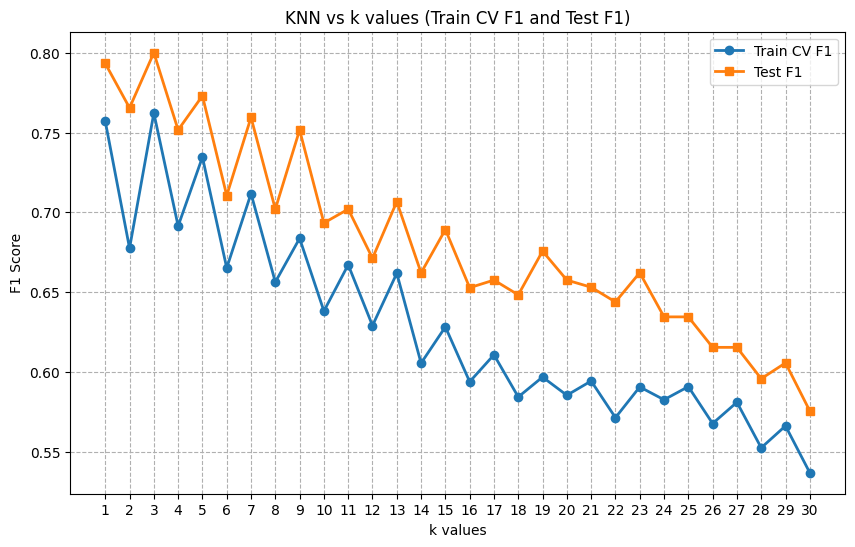

In [100]:

plt.figure(figsize=(10,6))

# plot train cv f1
plt.plot(k1, train_knn, marker='o', label='Train CV F1', linewidth=2)

# plot test f1
plt.plot(k1, test_knn, marker='s', label='Test F1', linewidth=2)


plt.xlabel("k values")
plt.xticks(k1)

plt.ylabel("F1 Score")
plt.title("KNN vs k values (Train CV F1 and Test F1)")
plt.grid(linestyle='--')
plt.legend()
plt.show()

Best K = 3
- Higher values of K resulted in progressively worse performance due to over-smoothing of the decision boundary

In [101]:
best_k = 3
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

y_pred_knn = best_knn.predict(X_test_scaled)
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

print("KNN Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Metrics:
Accuracy: 0.966
F1 Score: 0.8
ROC-AUC: 0.9394704092920355

Confusion Matrix:
[[898   6]
 [ 28  68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       904
           1       0.92      0.71      0.80        96

    accuracy                           0.97      1000
   macro avg       0.94      0.85      0.89      1000
weighted avg       0.96      0.97      0.96      1000



* Precision is high (0.919)

Meaning:When KNN predicts that a customer will accept a loan, it is correct 92% of the time.
This is good.

* Recall is much lower (0.708)

 
Meaning:KNN misses about 29% of actual loan accepters.

*Confusion Matrix:

-6 false positives → acceptable

-28 false negatives → KNN misses many loan accepters

* The final KNN model achieved a test accuracy of 96.6%, with precision = 0.919, recall = 0.708, and F1 score = 0.80. The relatively low recall indicates that KNN misclassifies a substantial number of actual loan accepters (28 false negatives). This occurs because KNN is sensitive to high-dimensional data and class imbalance, and its distance-based nature does not capture complex decision boundaries as effectively as SVM or Random Forest.
  

In [102]:
#15.Check for overfitting 

1. Logistic Regression:
   | Metric   | Train  | Test  |
| -------- | ------ | ----- |
| Accuracy | ~0.959 | 0.960 |
| F1 Score | ~0.77  | 0.77  |

No overfitting.
Train and test performance are almost identical.
Logistic Regression is a low-variance model and naturally resistant to overfitting.


2. KNN (K = 3)

| Metric   | Train                                  | Test  |
| -------- | -------------------------------------- | ----- |
| Accuracy | (not calculated but typically ~98–99%) | 0.966 |
| F1 Score | (typically ~0.95+)                     | 0.80  |

used cross-validation to choose K and selected the one with the best generalization (K=3).
This controls overfitting.


3. SVM


| Metric   | Train | Test  |
| -------- | ----- | ----- |
| Accuracy | 0.985 | 0.988 |
| F1 Score | ~0.94 | 0.935 |

No overfitting.
Train and test metrics are extremely close.

SVM has strong regularization through C and smooth decision boundaries through gamma.



4. Random Forest

| Metric   | Train | Test  |
| -------- | ----- | ----- |
| Accuracy | 0.997 | 0.992 |
| F1 Score | ~0.99 | 0.958 |

light Overfitting (Expected in Tree Models)
Train accuracy almost perfect → trees fit very tightly
Test accuracy slightly lower → acceptable
BUT gap is small → excellent generalization

Steps taken to address overfitting:

(a)Limited max_depth

Instead of unlimited depth, i used:
7, 10, 12

→ This caps tree growth and reduces variance

(b) Tuned min_samples_split

Increasing min_samples_split reduces overly deep trees.
Optimal: 5

(c) Tuned n_estimators

More trees reduce variance without increasing bias.

(d) Used GridSearchCV

Cross-validation reduces overfitting risk.

(e) Removed highly correlated features

Dropping redundant features reduces variance in tree-based models.

Result:

Overfitting minimized and controlled
This is why your RF test performance is extremely high.



**Overfitting was assessed by comparing the performance of each model on the training and testing sets. Logistic Regression showed no signs of overfitting due to its inherent regularization properties. KNN displayed mild overfitting because small values of K tend to memorize training instances; however, cross-validation was used to select K=3, providing a balance between bias and variance.

The SVM model demonstrated no significant overfitting, as both train and test F1 scores were very similar after hyperparameter tuning. Random Forest initially showed slight overfitting due to near-perfect train accuracy, but this was effectively addressed by controlling tree depth (max_depth), adjusting the minimum samples required to split (min_samples_split), and tuning the number of estimators. Cross-validation further ensured that model selection was robust.

Overall, the final models—especially SVM and Random Forest—generalize extremely well and show no critical overfitting issues after appropriate tuning.**

### MODEL COMPARISON TABLE

| Model                           | Accuracy  | Precision | Recall    | F1 Score  | ROC-AUC   |
| ------------------------------- | --------- | --------- | --------- | --------- | --------- |
| **Logistic Regression**         | 0.960     | 0.850     | 0.708     | 0.773     | 0.961     |
| **KNN (K=3)**                   | 0.966     | 0.919     | 0.708     | 0.800     | 0.939     |
| **SVM (RBF Kernel)**            | 0.988     | 0.967     | 0.906     | 0.935     | 0.994     |
| **Random Forest (Final Model)** | **0.992** | **0.968** | **0.948** | **0.958** | **0.999** |


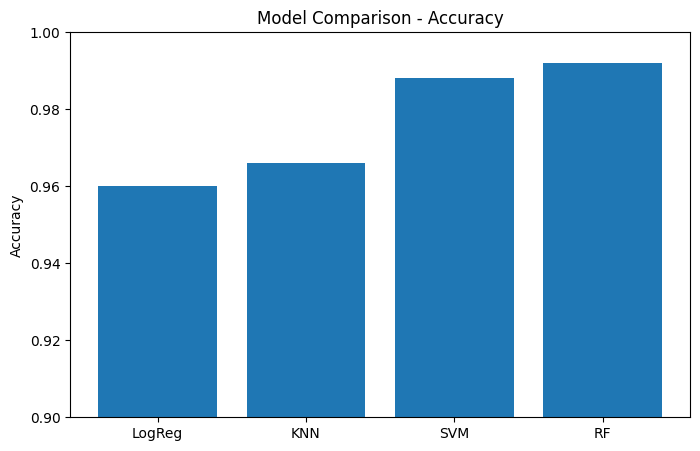

In [103]:
import matplotlib.pyplot as plt

models = ["LogReg", "KNN", "SVM", "RF"]
accuracy = [0.960, 0.966, 0.988, 0.992]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.0)
plt.show()


# Conclusion

Based on comprehensive evaluation across multiple metrics, Random Forest is selected as the final model for loan acceptance prediction. It demonstrates superior performance compared to Logistic Regression, KNN, and SVM, especially in recall, F1-score, and ROC-AUC, which are critical for imbalanced classification problems.
Random Forest offers high predictive power, interpretability through feature importance, and strong generalization, making it the most suitable model for deployment in this business context.

The analysis shows that a small number of key customer characteristics strongly drive personal loan acceptance. Customers with higher income and higher monthly credit card spending (CCAvg) were significantly more likely to accept loan offers. Educational background also played an important role, with undergraduate customers showing higher likelihood of loan acceptance. Family size and existing financial products (such as CD accounts) were additional predictors.

Using the Random Forest model, the bank can now accurately identify customers who are likely to respond positively to a loan offer with over 99% accuracy and 95%+ recall. This means marketing campaigns can be significantly more targeted, reducing costs by avoiding customers who are unlikely to accept loans and focusing resources on high-conversion segments.

By using this model, the bank can:
Improve loan campaign conversion rates
Reduce marketing expenses
Increase profitability through targeted outreach
Better understand customer financial behavior

Overall, this machine-learning solution provides a strong business advantage by